# Customer Churn Prediction
## Preprocessing Technique 06 — Standardization and Scaling
**Member: Fatheen-IT25103175**

This notebook follows the structure of the uploaded **Normalization & Scaling** reference notebook and is adapted to the Bank Customer Churn dataset.

### Why scaling is needed
The numerical predictors are measured on very different scales.

Examples:
- `CreditScore` is in the hundreds.
- `Age` is measured in years.
- `Balance` and `EstimatedSalary` can contain very large monetary values.
- Engineered ratio features can have very different ranges.

Scale-sensitive algorithms such as Logistic Regression, KNN, SVM and Neural Networks can be affected when predictors have very different magnitudes.

This notebook uses **StandardScaler**, which transforms selected numerical features so that they have approximately:
- Mean = 0
- Standard deviation = 1


In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load the Feature-Engineered Dataset

This is the final individual preprocessing notebook.

It expects the output from Feature Engineering:

`05_feature_engineered_churn_data.csv`


In [2]:
from google.colab import files

uploaded = files.upload()

Saving 05_feature_engineered_churn_data.csv to 05_feature_engineered_churn_data.csv


In [3]:
possible_paths = [
    Path("/content/05_feature_engineered_churn_data.csv"),
    Path("05_feature_engineered_churn_data.csv")
]

file_path = None

for path in possible_paths:
    if path.exists():
        file_path = path
        break

if file_path is None:
    raise FileNotFoundError(
        "05_feature_engineered_churn_data.csv was not found. "
        "Run Notebook 05 - Feature Engineering first, "
        "or upload its output CSV to Colab."
    )

df = pd.read_csv(file_path)

print("Loaded file:", file_path)
print("Dataset shape:", df.shape)

df.head()


Loaded file: /content/05_feature_engineered_churn_data.csv
Dataset shape: (15354, 18)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Exited,BalanceSalaryRatio,TenureByAge,BalancePerProduct,ProductsPerTenure,ActiveWithCard,IsZeroBalance
0,619,0,42,2,0.00,1,1,1,101348.88,0,0,1,0.000000,0.047619,0.000000,0.333333,1,1
1,608,0,41,1,83807.86,1,0,1,112542.58,0,1,0,0.744677,0.024390,83807.860000,0.500000,0,0
2,502,0,42,8,159660.80,3,1,0,113931.57,0,0,1,1.401375,0.190476,53220.266667,0.333333,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0,0.000000,0.025641,0.000000,1.000000,0,1
4,850,0,43,2,125510.82,1,1,1,79084.10,0,1,0,1.587055,0.046512,125510.820000,0.333333,1,0


## 2. Initial Dataset Inspection


In [4]:
print("Dataset Information")
print("-" * 60)
df.info()

print("\nMissing values:")
display(df.isnull().sum().to_frame(name="Missing Values"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe().T)


Dataset Information
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15354 entries, 0 to 15353
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         15354 non-null  int64  
 1   Gender              15354 non-null  int64  
 2   Age                 15354 non-null  int64  
 3   Tenure              15354 non-null  int64  
 4   Balance             15354 non-null  float64
 5   NumOfProducts       15354 non-null  int64  
 6   HasCrCard           15354 non-null  int64  
 7   IsActiveMember      15354 non-null  int64  
 8   EstimatedSalary     15354 non-null  float64
 9   Geography_Germany   15354 non-null  int64  
 10  Geography_Spain     15354 non-null  int64  
 11  Exited              15354 non-null  int64  
 12  BalanceSalaryRatio  15354 non-null  float64
 13  TenureByAge         15354 non-null  float64
 14  BalancePerProduct   1

,Missing Values
CreditScore,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0
Geography_Germany,0



Duplicate rows: 5786

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
CreditScore,15354.0,649.056858,96.570483,383.000000,581.000000,650.000000,717.000000,850.000000
Gender,15354.0,0.506187,0.499978,0.000000,0.000000,1.000000,1.000000,1.000000
Age,15354.0,39.988928,9.357647,18.000000,33.000000,39.000000,46.000000,62.000000
Tenure,15354.0,4.977791,2.908620,0.000000,2.000000,5.000000,8.000000,10.000000
Balance,15354.0,82021.868164,61512.435186,0.000000,0.000000,102967.410000,129303.637500,250898.090000
NumOfProducts,15354.0,1.473948,0.607176,1.000000,1.000000,1.000000,2.000000,3.000000
HasCrCard,15354.0,0.702814,0.457034,0.000000,0.000000,1.000000,1.000000,1.000000
IsActiveMember,15354.0,0.448482,0.497355,0.000000,0.000000,0.000000,1.000000,1.000000
EstimatedSalary,15354.0,100104.387220,57448.929489,11.580000,51123.652500,100329.780000,149756.710000,199992.480000
Geography_Germany,15354.0,0.301094,0.458748,0.000000,0.000000,0.000000,1.000000,1.000000


## 3. Select Features for Standardization

Only continuous/count numerical predictors are standardized.

The following types of columns are **not scaled**:
- `Exited` — target variable
- `Gender` — binary encoded feature
- `HasCrCard` — binary feature
- `IsActiveMember` — binary feature
- `ActiveWithCard` — engineered binary feature
- `IsZeroBalance` — engineered binary feature
- `Geography_*` — one-hot encoded dummy variables

Keeping binary/dummy variables as 0 and 1 makes them easier to interpret.


In [5]:
preferred_scale_cols = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary",
    "BalanceSalaryRatio",
    "TenureByAge",
    "BalancePerProduct",
    "ProductsPerTenure"
]

scale_cols = [
    col for col in preferred_scale_cols
    if col in df.columns
]

excluded_binary_cols = [
    col for col in df.columns
    if (
        col in [
            "Gender",
            "HasCrCard",
            "IsActiveMember",
            "ActiveWithCard",
            "IsZeroBalance"
        ]
        or col.startswith("Geography_")
    )
]

print("Features selected for StandardScaler:")
print(scale_cols)

print("\nBinary / dummy columns kept unchanged:")
print(excluded_binary_cols)

print("\nTarget kept unchanged: Exited")


Features selected for StandardScaler:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'BalanceSalaryRatio', 'TenureByAge', 'BalancePerProduct', 'ProductsPerTenure']

Binary / dummy columns kept unchanged:
['Gender', 'HasCrCard', 'IsActiveMember', 'Geography_Germany', 'Geography_Spain', 'ActiveWithCard', 'IsZeroBalance']

Target kept unchanged: Exited


## 4. Check Skewness of Numerical Features

Skewness helps us understand whether numerical variables are symmetric or strongly concentrated on one side.

This step is included for EDA and follows the structure of the reference scaling notebook.


In [6]:
skew_values = (
    df[scale_cols]
    .skew()
    .sort_values(ascending=False)
)

skew_table = skew_values.to_frame(
    name="Skewness"
)

display(skew_table)


,Skewness
BalanceSalaryRatio,81.844943
ProductsPerTenure,2.984578
NumOfProducts,0.899430
TenureByAge,0.592056
Age,0.244655
BalancePerProduct,0.170937
Tenure,0.025407
EstimatedSalary,-0.003482
CreditScore,-0.047578
Balance,-0.268725


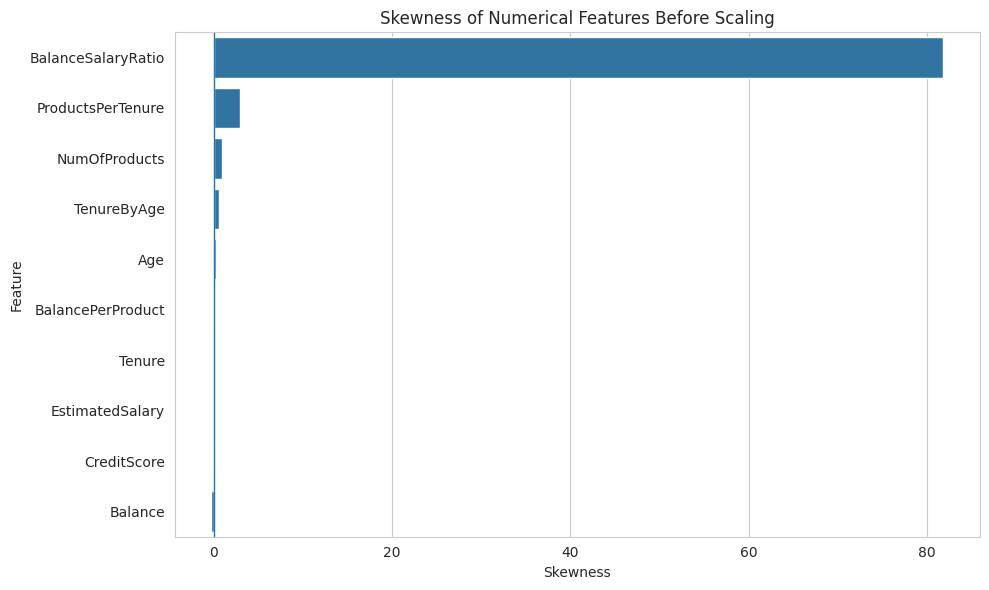

In [7]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=skew_values.values,
    y=skew_values.index
)

plt.axvline(0, linewidth=1)
plt.title("Skewness of Numerical Features Before Scaling")
plt.xlabel("Skewness")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


## 5. EDA Before Standardization — Distributions

The histograms below show the original scale and distribution of each numerical feature.


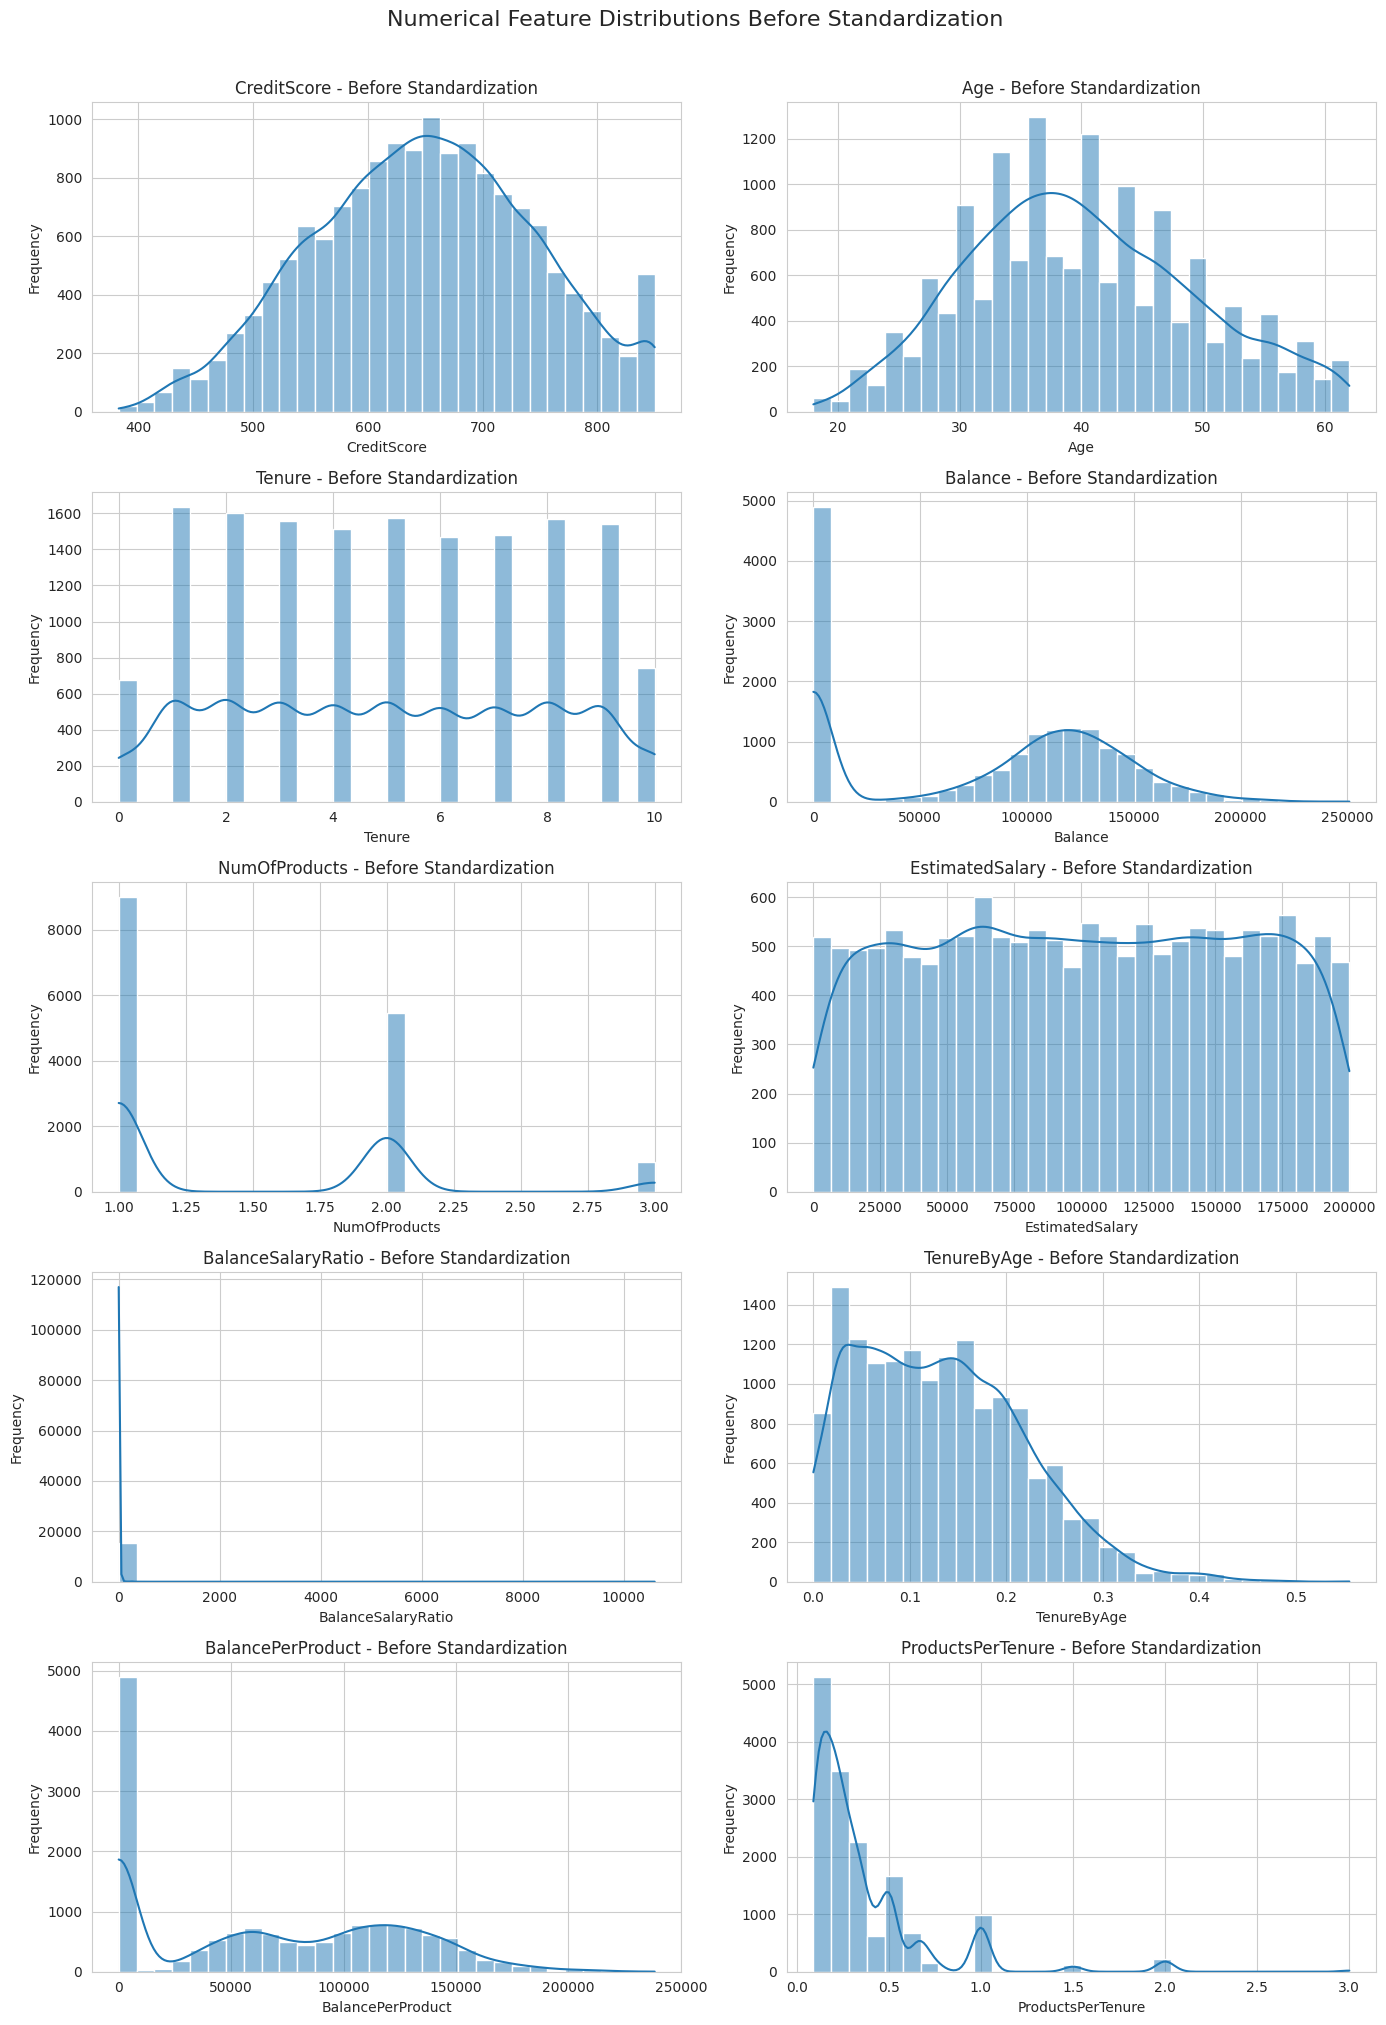

In [8]:
n_cols = 2
n_rows = int(np.ceil(len(scale_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, col in enumerate(scale_cols):
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} - Before Standardization")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(len(scale_cols), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Numerical Feature Distributions Before Standardization",
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()


## 6. EDA Before Standardization — Boxplots

The different numerical ranges are clearly visible before scaling.


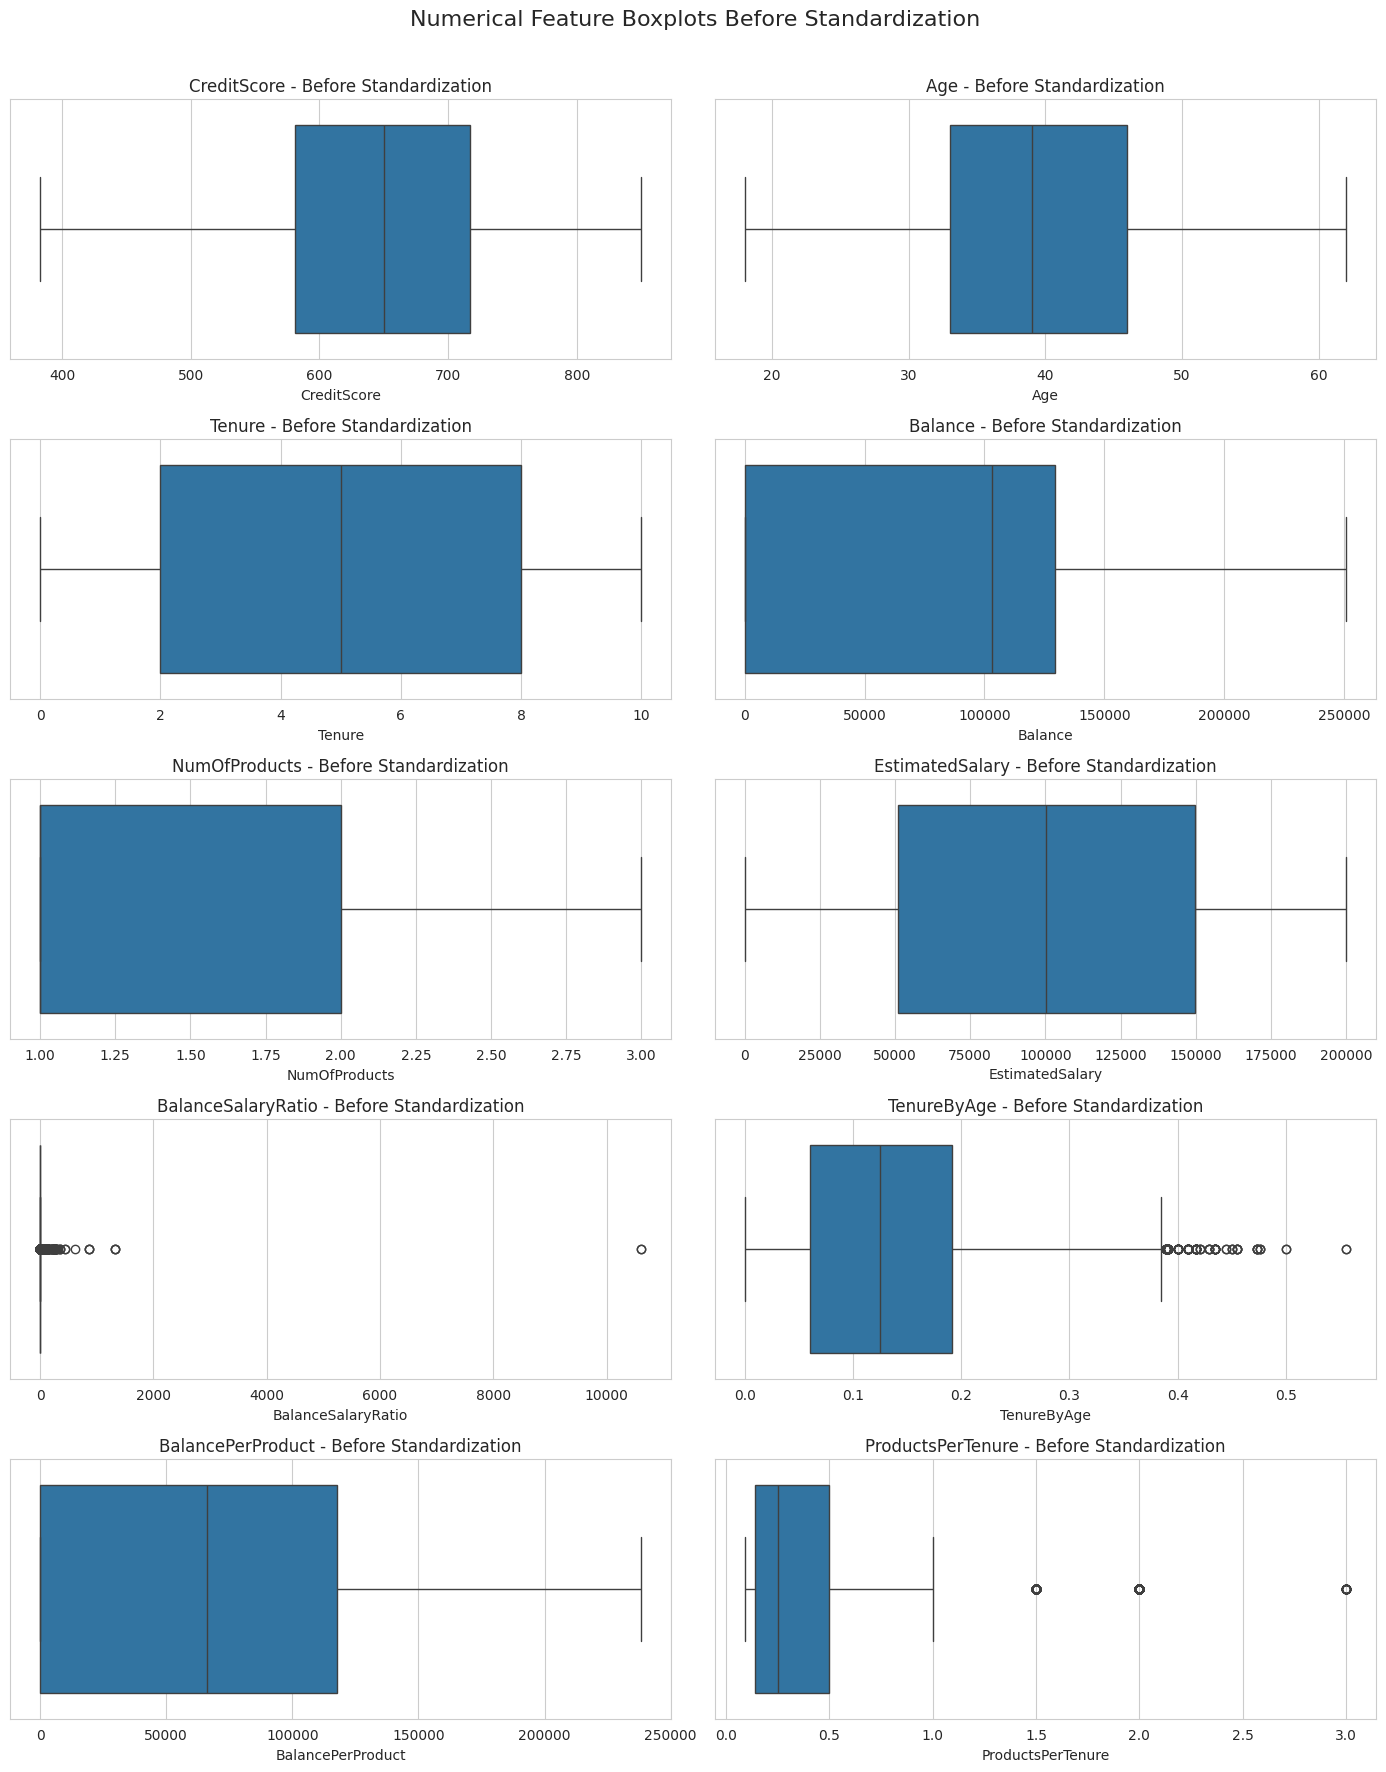

In [9]:
n_cols = 2
n_rows = int(np.ceil(len(scale_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 3.5 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, col in enumerate(scale_cols):
    sns.boxplot(
        data=df,
        x=col,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} - Before Standardization")

for j in range(len(scale_cols), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Numerical Feature Boxplots Before Standardization",
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()


## 7. Apply StandardScaler

Standardization uses the idea:

`z = (x - mean) / standard deviation`

After standardization:
- values are centered around 0
- the standard deviation is approximately 1
- the original distribution shape is preserved
- the units of measurement are removed

For this individual preprocessing notebook, a standardized copy of the complete processed dataset is created for EDA and export.


In [10]:
scaler = StandardScaler()

df_scaled = df.copy()

df_scaled[scale_cols] = scaler.fit_transform(
    df[scale_cols]
)

print("Standardization completed successfully!")

display(
    df_scaled[scale_cols]
    .describe()
    .T[["mean", "std", "min", "max"]]
)


Standardization completed successfully!


,mean,std,min,max
CreditScore,4.137197e-16,1.000033,-2.755143,2.080860
Age,-5.923503e-17,1.000033,-2.349912,2.352278
Tenure,-5.738394e-17,1.000033,-1.711449,1.726720
Balance,8.144817e-17,1.000033,-1.333463,2.745489
NumOfProducts,9.625693e-17,1.000033,-0.780603,2.513442
EstimatedSalary,1.883489e-16,1.000033,-1.742349,1.738785
BalanceSalaryRatio,1.851095e-18,1.000033,-0.037082,85.530777
TenureByAge,-1.184701e-16,1.000033,-1.529104,4.894350
BalancePerProduct,-5.183065e-17,1.000033,-1.190081,2.968529
ProductsPerTenure,-5.738394e-17,1.000033,-0.782158,7.711204


## 8. Verify Mean and Standard Deviation After Scaling

Because pandas uses sample standard deviation by default while `StandardScaler` uses population standard deviation, the displayed pandas standard deviation can be extremely close to 1 rather than exactly 1.


In [11]:
verification = pd.DataFrame({
    "Mean After Scaling":
        df_scaled[scale_cols].mean(),

    "Population Std After Scaling":
        df_scaled[scale_cols].std(ddof=0)
})

display(
    verification.round(6)
)


,Mean After Scaling,Population Std After Scaling
CreditScore,0.0,1.0
Age,-0.0,1.0
Tenure,-0.0,1.0
Balance,0.0,1.0
NumOfProducts,0.0,1.0
EstimatedSalary,0.0,1.0
BalanceSalaryRatio,0.0,1.0
TenureByAge,-0.0,1.0
BalancePerProduct,-0.0,1.0
ProductsPerTenure,-0.0,1.0


## 9. Before vs After Standardization — Example Features

The following graphs compare selected features before and after StandardScaler.

Standardization changes the scale, but it does not fundamentally change the shape of the distribution.


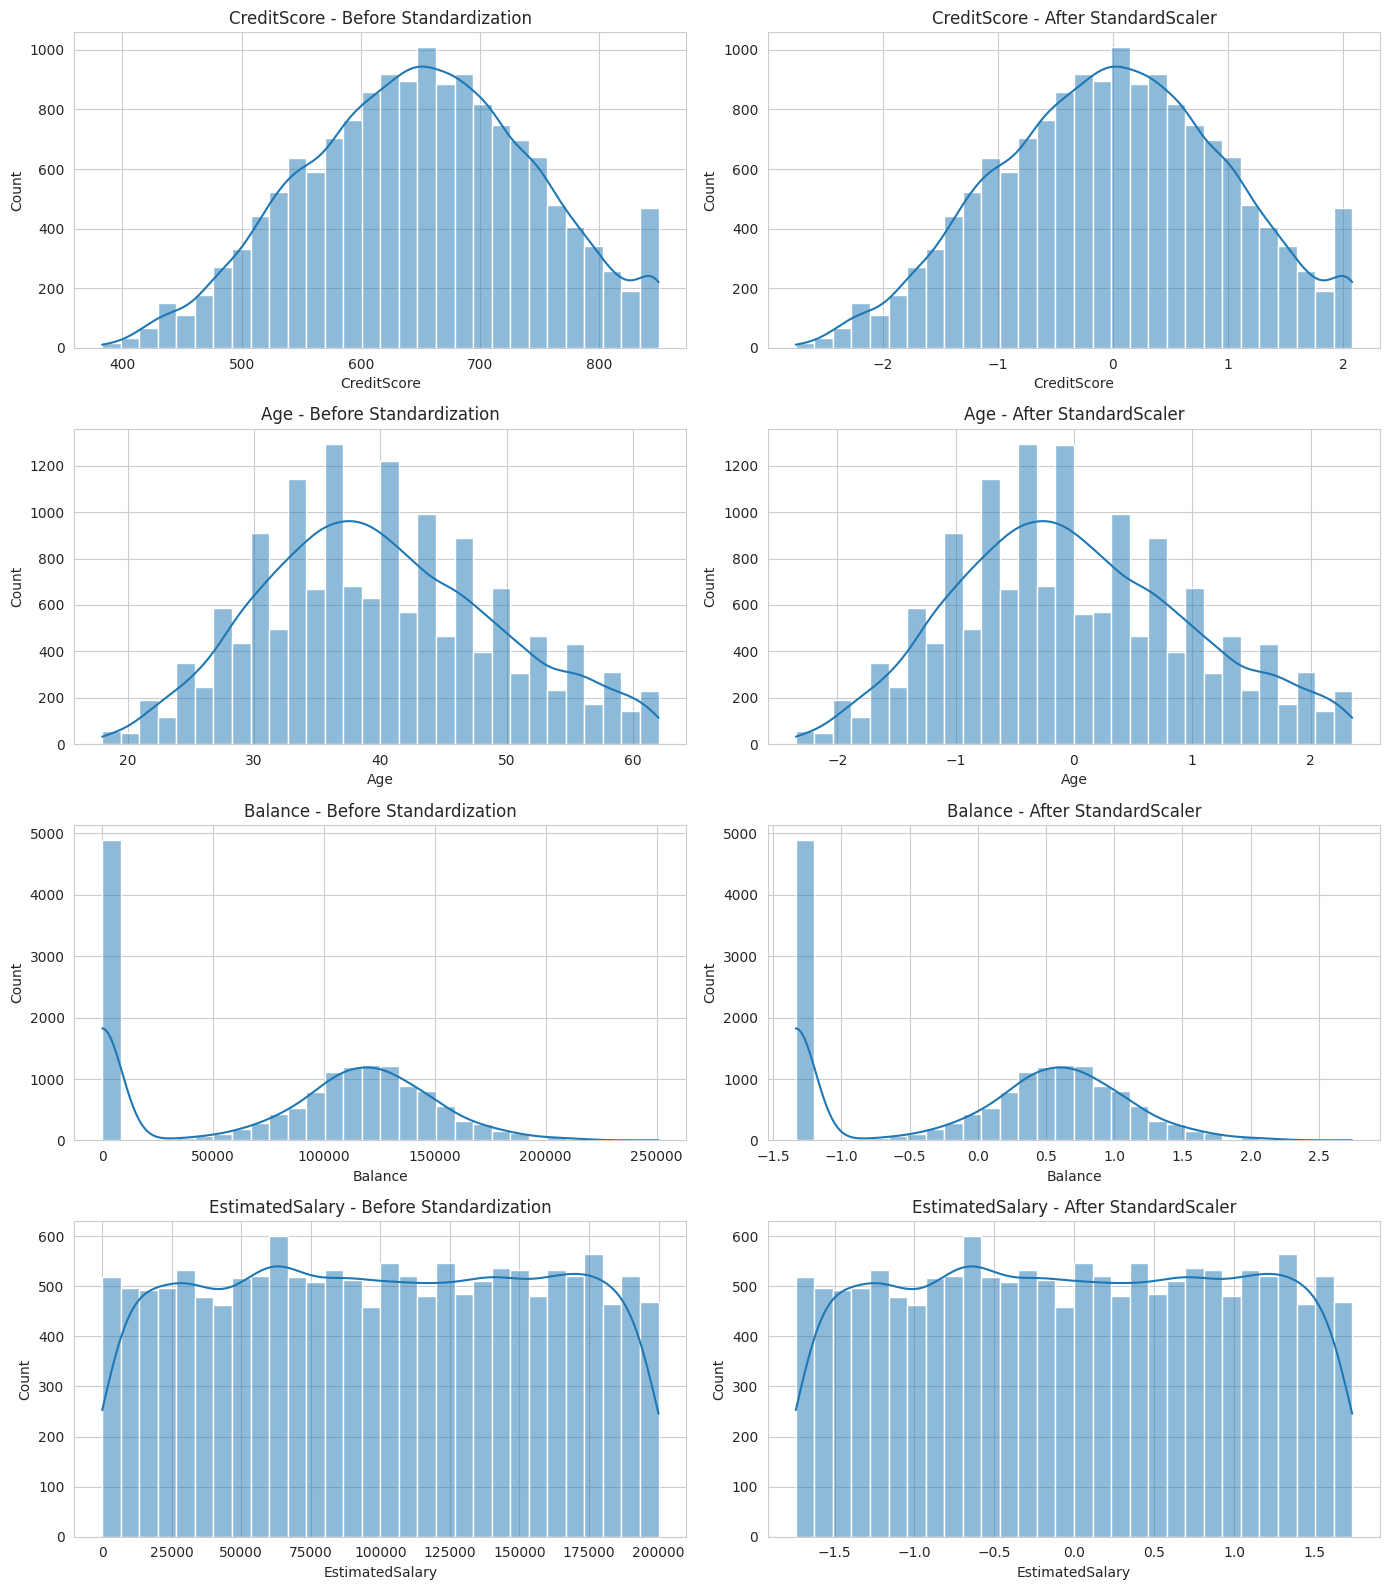

In [12]:
example_features = [
    col for col in [
        "CreditScore",
        "Age",
        "Balance",
        "EstimatedSalary"
    ]
    if col in scale_cols
]

fig, axes = plt.subplots(
    len(example_features),
    2,
    figsize=(14, 4 * len(example_features))
)

if len(example_features) == 1:
    axes = np.array([axes])

for i, col in enumerate(example_features):

    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(
        f"{col} - Before Standardization"
    )

    sns.histplot(
        df_scaled[col],
        bins=30,
        kde=True,
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(
        f"{col} - After StandardScaler"
    )

plt.tight_layout()
plt.show()


## 10. Compare Numerical Ranges Before and After


In [13]:
range_comparison = pd.DataFrame({
    "Before Min":
        df[scale_cols].min(),

    "Before Max":
        df[scale_cols].max(),

    "After Min":
        df_scaled[scale_cols].min(),

    "After Max":
        df_scaled[scale_cols].max(),

    "After Mean":
        df_scaled[scale_cols].mean(),

    "After Population Std":
        df_scaled[scale_cols].std(ddof=0)
})

display(
    range_comparison.round(4)
)


,Before Min,Before Max,After Min,After Max,After Mean,After Population Std
CreditScore,383.0000,850.0000,-2.7551,2.0809,0.0,1.0
Age,18.0000,62.0000,-2.3499,2.3523,-0.0,1.0
Tenure,0.0000,10.0000,-1.7114,1.7267,-0.0,1.0
Balance,0.0000,250898.0900,-1.3335,2.7455,0.0,1.0
NumOfProducts,1.0000,3.0000,-0.7806,2.5134,0.0,1.0
EstimatedSalary,11.5800,199992.4800,-1.7423,1.7388,0.0,1.0
BalanceSalaryRatio,0.0000,10614.6554,-0.0371,85.5308,0.0,1.0
TenureByAge,0.0000,0.5556,-1.5291,4.8944,-0.0,1.0
BalancePerProduct,0.0000,238387.5600,-1.1901,2.9685,-0.0,1.0
ProductsPerTenure,0.0909,3.0000,-0.7822,7.7112,-0.0,1.0


## 11. Target Distribution After Standardization

The target variable must remain unchanged because feature scaling should only transform predictor variables.


,Before Scaling,After Scaling
Exited,,
0,7677,7677
1,7677,7677


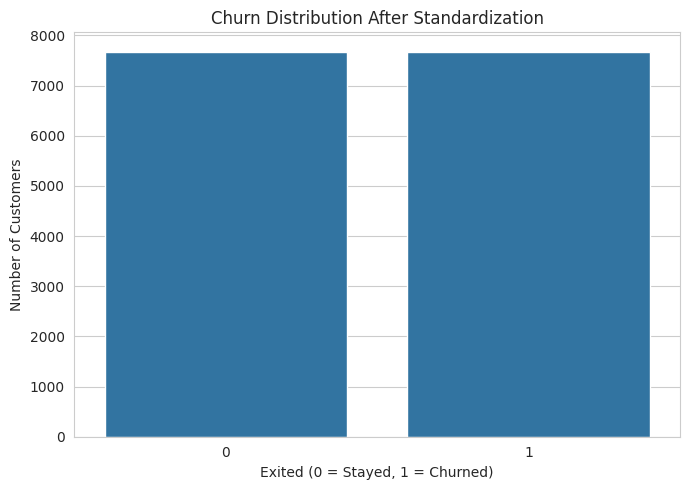

In [14]:
target_check = pd.DataFrame({
    "Before Scaling":
        df["Exited"].value_counts().sort_index(),

    "After Scaling":
        df_scaled["Exited"].value_counts().sort_index()
})

display(target_check)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_scaled,
    x="Exited"
)

plt.title("Churn Distribution After Standardization")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


## 12. Verify Binary and Dummy Features Were Not Changed


In [15]:
binary_check = []

for col in excluded_binary_cols:
    if col in df.columns:
        unchanged = df[col].equals(
            df_scaled[col]
        )

        binary_check.append({
            "Feature": col,
            "Unique Values Before":
                sorted(df[col].dropna().unique().tolist()),
            "Unique Values After":
                sorted(df_scaled[col].dropna().unique().tolist()),
            "Unchanged": unchanged
        })

binary_check_df = pd.DataFrame(binary_check)

display(binary_check_df)


,Feature,Unique Values Before,Unique Values After,Unchanged
0,Gender,"[0, 1]","[0, 1]",True
1,HasCrCard,"[0, 1]","[0, 1]",True
2,IsActiveMember,"[0, 1]","[0, 1]",True
3,Geography_Germany,"[0, 1]","[0, 1]",True
4,Geography_Spain,"[0, 1]","[0, 1]",True
5,ActiveWithCard,"[0, 1]","[0, 1]",True
6,IsZeroBalance,"[0, 1]","[0, 1]",True


## 13. Correlation Matrix After Scaling

Standardization changes feature magnitudes but does not change Pearson correlation relationships.

The heatmap is used as an EDA check after scaling.


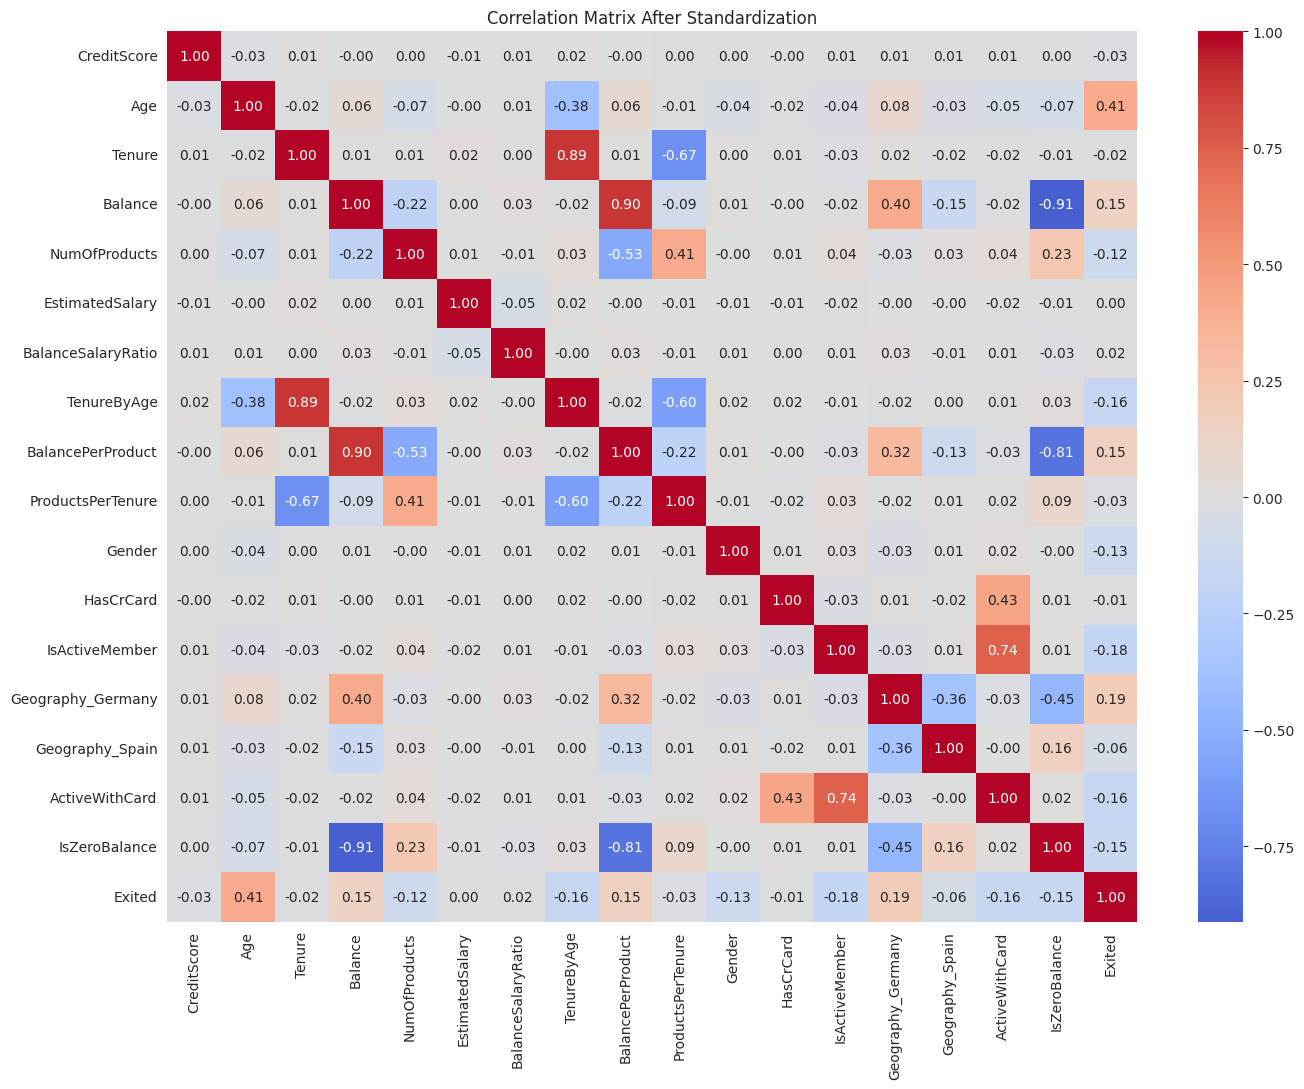

In [16]:
corr_features = scale_cols + [
    col for col in excluded_binary_cols
    if col in df_scaled.columns
] + ["Exited"]

# Remove accidental duplicates while preserving order
corr_features = list(
    dict.fromkeys(corr_features)
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    df_scaled[corr_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix After Standardization"
)

plt.tight_layout()
plt.show()


## 14. Correlation With the Target After Scaling


,Correlation with Exited
Age,0.405575
Geography_Germany,0.190675
BalancePerProduct,0.149048
Balance,0.148782
BalanceSalaryRatio,0.016781
EstimatedSalary,0.004446
HasCrCard,-0.008978
Tenure,-0.019862
CreditScore,-0.025636
ProductsPerTenure,-0.025703


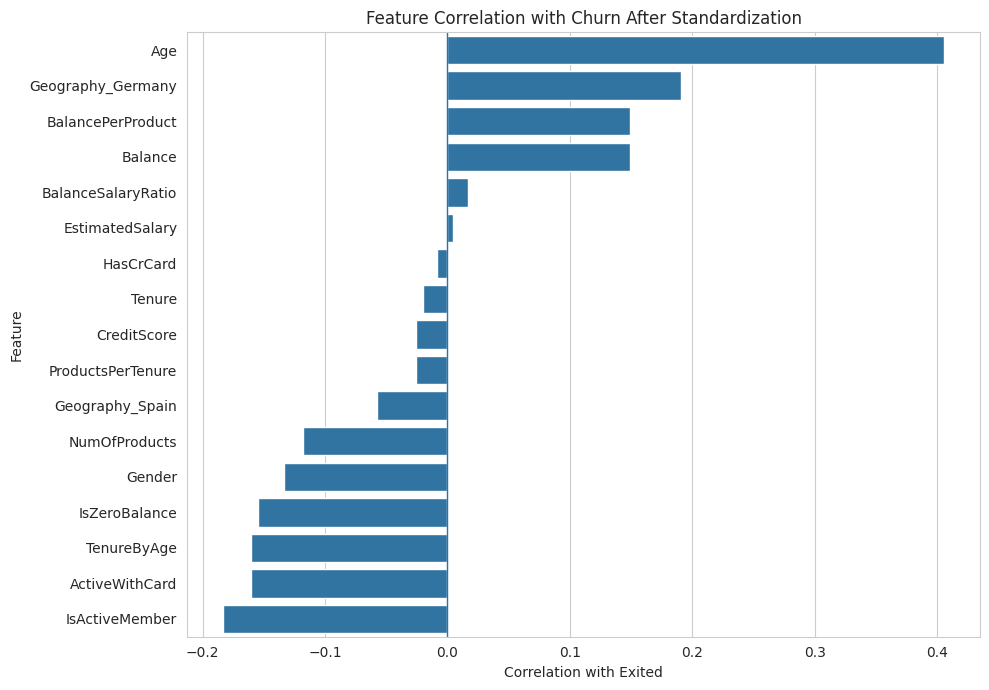

In [17]:
target_corr = (
    df_scaled[corr_features]
    .corr()["Exited"]
    .drop("Exited")
    .sort_values(ascending=False)
)

display(
    target_corr.to_frame(
        name="Correlation with Exited"
    )
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=target_corr.values,
    y=target_corr.index
)

plt.axvline(0, linewidth=1)
plt.title("Feature Correlation with Churn After Standardization")
plt.xlabel("Correlation with Exited")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


## 15. Leakage-Safe Scaling for Machine Learning

For final model training, the scaler should **not** be fitted on the complete dataset.

Correct procedure:

1. Split the data into training and test sets.
2. Fit `StandardScaler` only on the training features.
3. Use that fitted scaler to transform both training and test sets.

This prevents information from the test set from influencing preprocessing.


In [18]:
X = df.drop(
    columns=["Exited"]
)

y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape :", X_test.shape)
print("Training target shape :", y_train.shape)
print("Testing target shape  :", y_test.shape)


Training feature shape: (12283, 17)
Testing feature shape : (3071, 17)
Training target shape : (12283,)
Testing target shape  : (3071,)


In [19]:
train_scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit ONLY using training data
X_train_scaled[scale_cols] = (
    train_scaler.fit_transform(
        X_train[scale_cols]
    )
)

# Transform test data using training parameters
X_test_scaled[scale_cols] = (
    train_scaler.transform(
        X_test[scale_cols]
    )
)

print("Leakage-safe StandardScaler completed.")

print("\nTraining scaled means:")
display(
    X_train_scaled[scale_cols]
    .mean()
    .round(4)
    .to_frame("Training Mean")
)

print("\nTraining scaled population standard deviations:")
display(
    X_train_scaled[scale_cols]
    .std(ddof=0)
    .round(4)
    .to_frame("Training Population Std")
)


Leakage-safe StandardScaler completed.

Training scaled means:


,Training Mean
CreditScore,-0.0
Age,0.0
Tenure,-0.0
Balance,-0.0
NumOfProducts,-0.0
EstimatedSalary,-0.0
BalanceSalaryRatio,-0.0
TenureByAge,-0.0
BalancePerProduct,0.0
ProductsPerTenure,0.0



Training scaled population standard deviations:


,Training Population Std
CreditScore,1.0
Age,1.0
Tenure,1.0
Balance,1.0
NumOfProducts,1.0
EstimatedSalary,1.0
BalanceSalaryRatio,1.0
TenureByAge,1.0
BalancePerProduct,1.0
ProductsPerTenure,1.0


## 16. Store the Scaling Parameters

The learned means and scales can be inspected and reused later.

In a deployed machine-learning system, the same scaler fitted on training data must be used when transforming new customer records.


In [20]:
scaler_parameters = pd.DataFrame({
    "Feature": scale_cols,
    "Training Mean": train_scaler.mean_,
    "Training Scale": train_scaler.scale_
})

display(
    scaler_parameters
)


,Feature,Training Mean,Training Scale
0,CreditScore,648.326549,96.498801
1,Age,39.976227,9.333383
2,Tenure,4.986241,2.908951
3,Balance,81797.706235,61318.006356
4,NumOfProducts,1.470813,0.605162
5,EstimatedSalary,100316.783944,57433.644182
6,BalanceSalaryRatio,5.014189,138.439513
7,TenureByAge,0.132506,0.086650
8,BalancePerProduct,68160.399680,57228.041100
9,ProductsPerTenure,0.357517,0.341475


## 17. Before vs After Summary


In [21]:
summary = pd.DataFrame({
    "Measure": [
        "Number of Rows",
        "Number of Columns",
        "Total Missing Values",
        "Duplicate Rows",
        "Target Class 0 Count",
        "Target Class 1 Count"
    ],

    "Before Standardization": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        (df["Exited"] == 0).sum(),
        (df["Exited"] == 1).sum()
    ],

    "After Standardization": [
        df_scaled.shape[0],
        df_scaled.shape[1],
        df_scaled.isnull().sum().sum(),
        df_scaled.duplicated().sum(),
        (df_scaled["Exited"] == 0).sum(),
        (df_scaled["Exited"] == 1).sum()
    ]
})

display(summary)


,Measure,Before Standardization,After Standardization
0,Number of Rows,15354,15354
1,Number of Columns,18,18
2,Total Missing Values,0,0
3,Duplicate Rows,5786,5786
4,Target Class 0 Count,7677,7677
5,Target Class 1 Count,7677,7677


## 18. Save the Standardized Dataset

This is the final output of the six individual preprocessing stages.

### Output
`06_standardized_churn_data.csv`

This processed dataset can be used for model development and for demonstrating the complete preprocessing workflow.


In [22]:
if Path("/content").exists():
    output_file = "/content/06_standardized_churn_data.csv"
else:
    output_file = "06_standardized_churn_data.csv"

df_scaled.to_csv(
    output_file,
    index=False
)

print("Standardized dataset saved successfully!")
print("File:", output_file)
print("Final shape:", df_scaled.shape)


Standardized dataset saved successfully!
File: /content/06_standardized_churn_data.csv
Final shape: (15354, 18)


In [23]:
# Optional Google Colab download

try:
    from google.colab import files
    files.download(output_file)
except ImportError:
    print(
        "Google Colab download is not available "
        "in this environment."
    )


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
from google.colab import files

files.download("06_standardized_churn_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Interpretation

- The numerical predictors originally had very different measurement scales.
- After `StandardScaler`, the selected numerical features are centered around 0 with population standard deviation approximately 1.
- The target variable `Exited` is not scaled.
- Binary and one-hot encoded features remain unchanged as 0/1.
- Standardization does not remove records and does not change the churn class distribution.
- The leakage-safe section demonstrates how scaling should be fitted only on training data during actual model development.


## Conclusion

In this preprocessing stage:

- Numerical feature scales were examined using EDA.
- Skewness was inspected before scaling.
- Continuous/count numerical predictors were standardized using `StandardScaler`.
- Binary, dummy, and target variables were kept unchanged.
- Distributions were visualized before and after scaling.
- Correlations were checked after scaling.
- A leakage-safe train/test scaling procedure was demonstrated.
- The final standardized dataset was saved as `06_standardized_churn_data.csv`.

This completes the final individual preprocessing stage of the group project.
